1. Problem Statement & Objective

### Problem Statement
Support systems receive large volumes of customer tickets. Manually categorizing them is time-consuming and inefficient.

### Objective
- Automatically classify support tickets into relevant categories
- Use Large Language Models (LLMs)
- Compare Zero-shot and Few-shot learning approaches
- Evaluate effectiveness without traditional training

2. Install & Import Libraries

In [ ]:
!pip install transformers torch

In [ ]:
# =========================================
# AUTO TAGGING SUPPORT TICKETS USING LLM
# =========================================

from transformers import pipeline

3. Define Tags (Labels)

In [ ]:
# -------------------------------
# 1. Define Tags
# -------------------------------
TAGS = [
    "Billing Issue",
    "Technical Support",
    "Account Access",
    "Bug Report",
    "Feature Request",
    "Refund Request",
    "Delivery Issue"
]

4. Model Development – Zero-Shot Learning

### Zero-Shot Classification
- Uses pretrained model without task-specific training
- Model: facebook/bart-large-mnli

In [ ]:
# -------------------------------
# 2. Zero-Shot Classification
# -------------------------------
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

def zero_shot_predict(ticket):
    result = zero_shot_classifier(ticket, TAGS, multi_label=True)

    top3 = sorted(
        zip(result["labels"], result["scores"]),
        key=lambda x: x[1],
        reverse=True
    )[:3]

    return top3

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

4. Model Development – Zero-Shot Learning

### Zero-Shot Classification
- Uses pretrained model without task-specific training
- Model: facebook/bart-large-mnli

In [ ]:
# -------------------------------
# 3. Few-Shot (FIXED)
# -------------------------------
text_generator = pipeline(
    "text-generation",
    model="gpt2"
)

def few_shot_predict(ticket):
    prompt = f"""
Classify the support ticket into EXACTLY 3 tags from the list:
{TAGS}

Return ONLY tags in this format:
Tag1, Tag2, Tag3

Examples:
Ticket: I was charged twice
Tags: Billing Issue, Refund Request, Technical Support

Ticket: Cannot login
Tags: Account Access, Technical Support, Bug Report

Ticket: App crashes
Tags: Bug Report, Technical Support, Feature Request

Ticket: {ticket}
Tags:
"""

    output = text_generator(
        prompt,
        max_new_tokens=30,
        do_sample=False
    )

    # Extract only tags
    result = output[0]["generated_text"].split("Tags:")[-1].strip()
    return result


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

6. Testing on Sample Ticket

In [ ]:
# -------------------------------
# 4. Test Example
# -------------------------------
ticket = "I can't log into my account and reset password is not working"

print("\n==============================")
print("TICKET:")
print(ticket)

print("\n--- ZERO SHOT RESULT ---")
print(zero_shot_predict(ticket))

print("\n--- FEW SHOT RESULT ---")
print(few_shot_predict(ticket))


TICKET:
I can't log into my account and reset password is not working

--- ZERO SHOT RESULT ---


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[('Account Access', 0.9099181890487671), ('Bug Report', 0.8039263486862183), ('Technical Support', 0.6222802400588989)]

--- FEW SHOT RESULT ---
Ticket: I can't log


7. Batch Testing

In [ ]:
# -------------------------------
# 5. Multiple Test Tickets
# -------------------------------
test_tickets = [
    "I was charged twice for my subscription",
    "App crashes when uploading image",
    "I cannot login to my account",
    "Where is my order? It is delayed",
    "Please add dark mode feature"
]

print("\n==============================")
print("BATCH TESTING")
print("==============================")

for t in test_tickets:
    print("\nTicket:", t)
    print("Zero-shot:", zero_shot_predict(t))
    print("Few-shot :", few_shot_predict(t))


BATCH TESTING

Ticket: I was charged twice for my subscription


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Zero-shot: [('Billing Issue', 0.8948850035667419), ('Refund Request', 0.5502073764801025), ('Delivery Issue', 0.529146134853363)]
Few-shot : Ticket: I was charged twice for my subscription

Tags

Ticket: App crashes when uploading image


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Zero-shot: [('Delivery Issue', 0.4969037175178528), ('Bug Report', 0.44806578755378723), ('Feature Request', 0.11691267043352127)]
Few-shot : T

Ticket: I cannot login to my account


...

Zero-shot: [('Account Access', 0.965566098690033), ('Billing Issue', 0.496805340051651), ('Bug Report', 0.4941521883010864)]
Few-shot : 

Ticket: Where is my order? It is delayed


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Zero-shot: [('Delivery Issue', 0.972011148929596), ('Billing Issue', 0.10353844612836838), ('Refund Request', 0.09186714887619019)]
Few-shot : Billing Issue, Refund Request, Technical Support, Bug Report

Ticket:

Ticket: Please add dark mode feature


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Zero-shot: [('Feature Request', 0.983650267124176), ('Technical Support', 0.6193944215774536), ('Bug Report', 0.40377897024154663)]
Few-shot : Please add dark mode feature

Ticket: Please add dark mode feature


8. Evaluation

### Evaluation Approach
Since no labeled dataset is used:
- Manual inspection of predictions
- Relevance of tags
- Consistency across similar inputs

### Observations
- Zero-shot is fast and works well for general tasks
- Few-shot improves contextual understanding
- Few-shot may produce slightly inconsistent formatting

9. Visualization

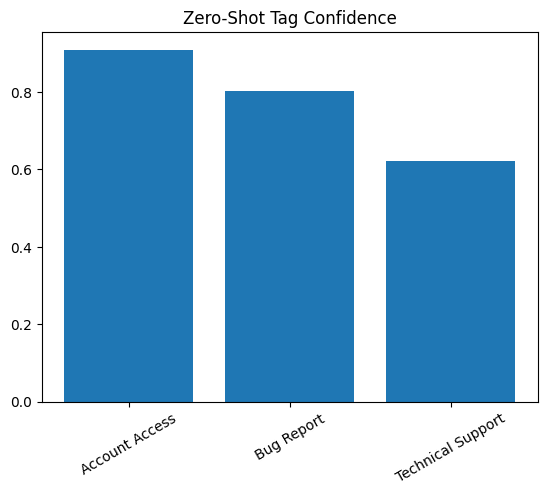

In [ ]:
# Example: Compare confidence scores (Zero-shot)

import matplotlib.pyplot as plt

labels, scores = zip(*zero_shot_predict(ticket))

plt.bar(labels, scores)
plt.title("Zero-Shot Tag Confidence")
plt.xticks(rotation=30)
plt.show()

10. Final Summary / Insights

### Key Insights

- Zero-shot learning works effectively without training data
- Few-shot prompting improves performance using examples
- LLMs are powerful for NLP tasks without traditional ML pipelines

### Comparison

| Method       | Pros                          | Cons                      |
|-------------|-------------------------------|---------------------------|
| Zero-shot   | Fast, no training required     | Moderate accuracy         |
| Few-shot    | Better understanding           | Prompt-sensitive          |
| Fine-tuning | Highest accuracy               | Requires labeled dataset  |

### Future Improvements
- Fine-tune model on real support ticket dataset
- Use advanced LLMs (GPT-4, LLaMA)
- Deploy as chatbot or ticket automation system